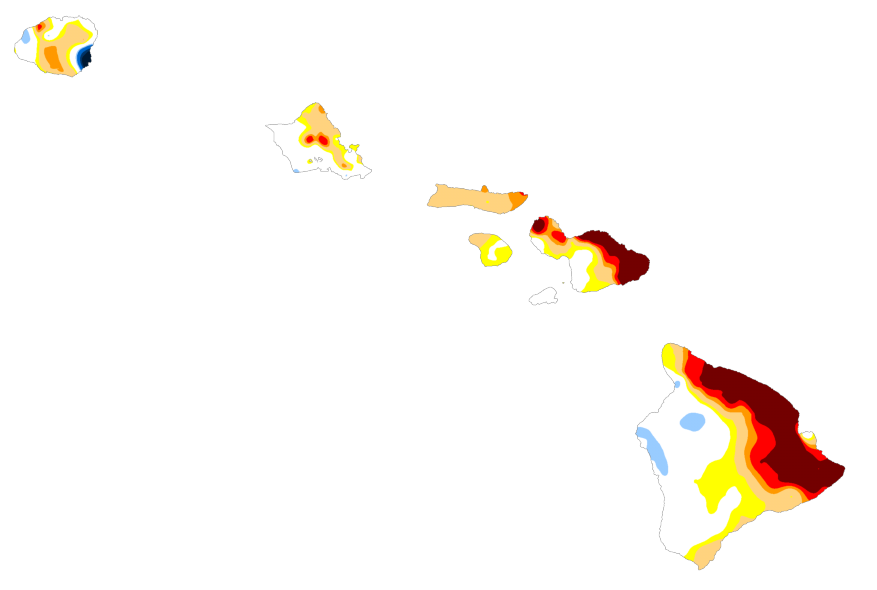

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

thresholds = [
    (-np.inf, -2, "#730000", "D4 Exceptional Drought"),
    (-2,   -1.6, "#FF0000", "D3 Extreme Drought"),
    (-1.6,   -1.3, "#FF9900", "D2 Severe Drought"),
    (-1.3,   -0.8, "#FFD37F", "D1 Moderate Drought"),
    (-0.8,    -0.5, "#FFFF00", "D0 Abnormally Dry"),
    (-0.5,    0.5, "#FFFFFF", "Near Normal"),
    ( 0.5,    0.8, "#99CCFF", "W0 Abnormally Wet"),
    ( 0.8,    1.3, "#0066CC", "W1 Moderately Wet"),
    ( 1.3,    1.6, "#0066CC", "W2 Severely Wet"),
    ( 1.6,    2.0, "#003366", "W3 Extremely Wet"),
    ( 2.0,  np.inf, "#001933", "W4 Exceptionally Wet"),
]


with rasterio.open(f"spi_month_timescale012_statewide_data_map_2025_12.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
# with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
#     dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

# cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
# cbar.set_ticks(range(len(colors)))
# cbar.set_ticklabels(labels)
# cbar.ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('../../public/climate-summary/spi12.png', dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()


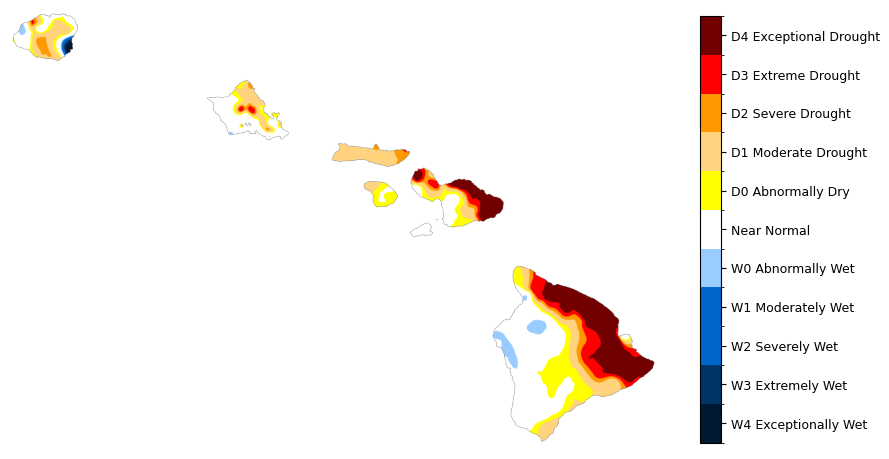

In [3]:
#for report add cbar
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

thresholds = [
    (-np.inf, -2, "#730000", "D4 Exceptional Drought"),
    (-2,   -1.6, "#FF0000", "D3 Extreme Drought"),
    (-1.6,   -1.3, "#FF9900", "D2 Severe Drought"),
    (-1.3,   -0.8, "#FFD37F", "D1 Moderate Drought"),
    (-0.8,    -0.5, "#FFFF00", "D0 Abnormally Dry"),
    (-0.5,    0.5, "#FFFFFF", "Near Normal"),
    ( 0.5,    0.8, "#99CCFF", "W0 Abnormally Wet"),
    ( 0.8,    1.3, "#0066CC", "W1 Moderately Wet"),
    ( 1.3,    1.6, "#0066CC", "W2 Severely Wet"),
    ( 1.6,    2.0, "#003366", "W3 Extremely Wet"),
    ( 2.0,  np.inf, "#001933", "W4 Exceptionally Wet"),
]


with rasterio.open(f"spi_month_timescale012_statewide_data_map_2025_12.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
# with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
#     dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)
cbar.ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../../public/climate-summary/pubs/Figure5.png', dpi=600, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()


<Figure size 900x600 with 0 Axes>

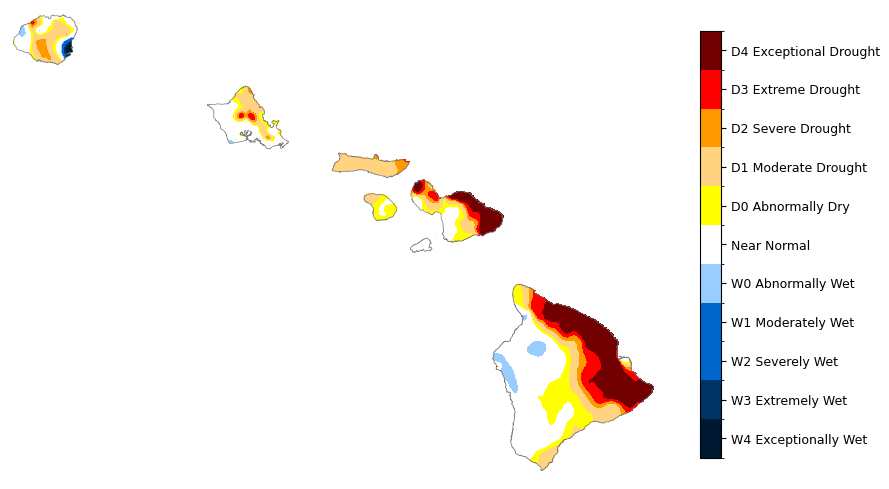

In [1]:
#for report add cbar
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from rasterio.plot import plotting_extent

thresholds = [
    (-np.inf, -2, "#730000", "D4 Exceptional Drought"),
    (-2,   -1.6, "#FF0000", "D3 Extreme Drought"),
    (-1.6,   -1.3, "#FF9900", "D2 Severe Drought"),
    (-1.3,   -0.8, "#FFD37F", "D1 Moderate Drought"),
    (-0.8,    -0.5, "#FFFF00", "D0 Abnormally Dry"),
    (-0.5,    0.5, "#FFFFFF", "Near Normal"),
    ( 0.5,    0.8, "#99CCFF", "W0 Abnormally Wet"),
    ( 0.8,    1.3, "#0066CC", "W1 Moderately Wet"),
    ( 1.3,    1.6, "#0066CC", "W2 Severely Wet"),
    ( 1.6,    2.0, "#003366", "W3 Extremely Wet"),
    ( 2.0,  np.inf, "#001933", "W4 Exceptionally Wet"),
]
coast_path = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/public/shapefiles/Coastline.shp"


with rasterio.open(f"spi_month_timescale012_statewide_data_map_2025_12.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata
    extent = rasterio.plot.plotting_extent(src)  # (left, right, bottom, top)
    raster_crs = src.crs

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
# with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
#     dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)
coast = gpd.read_file(coast_path)
if raster_crs is not None and coast.crs is not None and coast.crs != raster_crs:
    coast = coast.to_crs(raster_crs)
fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    categorical_masked,
    cmap=cmap,
    norm=norm,
    extent=extent,             # align raster with geodata
    interpolation="nearest",   # avoid halos
    resample=False
)


coast.boundary.plot(
    ax=ax,
    color="#6e6e6e",
    linewidth=0.5,
    alpha=0.9
)

plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)
cbar.ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../../public/climate-summary/pubs/Figure5.png', dpi=600, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()


In [6]:
import rasterio
import numpy as np
import pandas as pd
with rasterio.open(f"spi_month_timescale012_statewide_data_map_2025_12.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

valid = np.isfinite(data)

pct = np.sum((data < -1.3) & valid) / np.sum(valid) * 100
print(f"{pct:.2f}%")

30.72%


In [8]:
import numpy as np
import pandas as pd
import rasterio

thresholds = [
    (-np.inf, -2,   "#730000", "D4 Exceptional Drought"),
    (-2,      -1.6, "#FF0000", "D3 Extreme Drought"),
    (-1.6,    -1.3, "#FF9900", "D2 Severe Drought"),
    (-1.3,    -0.8, "#FFD37F", "D1 Moderate Drought"),
    (-0.8,    -0.5, "#FFFF00", "D0 Abnormally Dry"),
    (-0.5,     0.5, "#FFFFFF", "Near Normal"),
    ( 0.5,     0.8, "#99CCFF", "W0 Abnormally Wet"),
    ( 0.8,     1.3, "#0066CC", "W1 Moderately Wet"),
    ( 1.3,     1.6, "#0066CC", "W2 Severely Wet"),
    ( 1.6,     2.0, "#003366", "W3 Extremely Wet"),
    ( 2.0,   np.inf,"#001933", "W4 Exceptionally Wet"),
]
labels = [t[3] for t in thresholds]

rows = []

for m in range(1, 13):
    tif = f"/Users/cherryleheu/Documents/HCDP/Data/monthly/SPI/spi3_2025_{m:02d}.tif"
    with rasterio.open(tif) as src:
        data = src.read(1)
    valid = np.isfinite(data)

    total = valid.sum()
    out = {"month": f"{m:02d}"}

    for lo, hi, _, lab in thresholds:
        in_bin = (data >= lo) & (data < hi) & valid
        out[lab] = (in_bin.sum() / total) * 100.0

    rows.append(out)

df = pd.DataFrame(rows)
df


,month,D4 Exceptional Drought,D3 Extreme Drought,D2 Severe Drought,D1 Moderate Drought,D0 Abnormally Dry,Near Normal,W0 Abnormally Wet,W1 Moderately Wet,W2 Severely Wet,W3 Extremely Wet,W4 Exceptionally Wet
0,01,0.000000,0.561491,6.059385,15.277638,12.942431,45.385318,14.037981,5.164888,0.570867,0.000000,0.000000
1,02,7.288625,12.130230,9.648833,14.780386,12.348298,41.371539,2.136584,0.283697,0.011806,0.000000,0.000000
2,03,0.000000,0.000000,2.012966,19.478580,12.441359,58.415948,6.470868,1.180278,0.000000,0.000000,0.000000
3,04,4.878413,12.708389,9.287354,14.994982,12.284058,40.262446,3.920370,1.663987,0.000000,0.000000,0.000000
4,05,0.524684,5.312814,8.081033,15.478691,8.952959,49.382429,7.664689,4.470403,0.132299,0.000000,0.000000
5,06,2.967536,4.839522,6.114250,10.744731,6.417045,35.542376,12.022932,13.947351,4.992656,2.194227,0.217374
6,07,0.294462,2.623766,5.934725,19.767486,13.174736,52.220096,3.369296,1.735866,0.406274,0.462875,0.010417
7,08,2.268537,7.681009,11.046485,28.665581,17.310744,29.695850,1.866082,0.824007,0.269113,0.164246,0.208346
8,09,1.438279,6.269120,13.481351,29.177069,20.897761,27.064098,0.533018,0.627815,0.176052,0.101395,0.234042
9,10,2.759191,5.523937,8.669262,30.691742,18.383724,31.262956,1.933795,0.329881,0.107298,0.131952,0.206262


In [9]:
df.to_csv("../../public/climate-summary/spi3_distribution_2025.csv", index=False)

In [5]:
# import numpy as np
# import pandas as pd
# import rasterio

# thresholds = [
#     (-np.inf, -2,   "#730000", "D4 Exceptional Drought"),
#     (-2,      -1.6, "#FF0000", "D3 Extreme Drought"),
#     (-1.6,    -1.3, "#FF9900", "D2 Severe Drought"),
#     (-1.3,    -0.8, "#FFD37F", "D1 Moderate Drought"),
#     (-0.8,    -0.5, "#FFFF00", "D0 Abnormally Dry"),
#     (-0.5,     0.5, "#FFFFFF", "Near Normal"),
#     ( 0.5,     0.8, "#99CCFF", "W0 Abnormally Wet"),
#     ( 0.8,     1.3, "#0066CC", "W1 Moderately Wet"),
#     ( 1.3,     1.6, "#0066CC", "W2 Very Wet"),
#     ( 1.6,     2.0, "#003366", "W3 Extremely Wet"),
#     ( 2.0,   np.inf,"#001933", "W4 Exceptionally Wet"),
# ]
# labels = [t[3] for t in thresholds]

# rows = []

# for m in range(1, 13):
#     tif = f"/Users/cherryleheu/Documents/HCDP/Data/monthly/SPI/spi3_2025_{m:02d}.tif"
#     with rasterio.open(tif) as src:
#         data = src.read(1)
#     valid = np.isfinite(data)

#     total = valid.sum()
#     out = {"month": f"{m:02d}"}

#     for lo, hi, _, lab in thresholds:
#         in_bin = (data >= lo) & (data < hi) & valid
#         out[lab] = (in_bin.sum() / total) * 100.0

#     rows.append(out)

# df = pd.DataFrame(rows)
# df.to_csv("../../public/climate-summary/spi3_distribution_2025.csv", index=False)


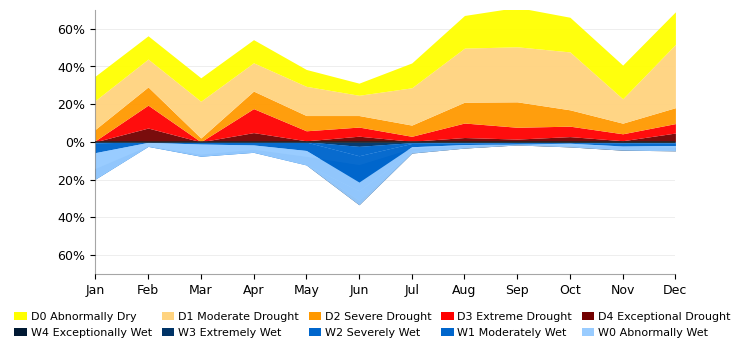

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, FuncFormatter

DROUGHT = [
    "D4 Exceptional Drought",
    "D3 Extreme Drought",
    "D2 Severe Drought",
    "D1 Moderate Drought",
    "D0 Abnormally Dry",
]

WET = [
    "W0 Abnormally Wet",
    "W1 Moderately Wet",
    "W2 Severely Wet",
    "W3 Extremely Wet",
    "W4 Exceptionally Wet",
]

NEAR_NORMAL = "Near Normal"

label2color = {
    "D4 Exceptional Drought": "#730000",
    "D3 Extreme Drought":     "#FF0000",
    "D2 Severe Drought":      "#FF9900",
    "D1 Moderate Drought":    "#FFD37F",
    "D0 Abnormally Dry":      "#FFFF00",
    "Near Normal":            "#FFFFFF",
    "W0 Abnormally Wet":      "#99CCFF",
    "W1 Moderately Wet":      "#0066CC",
    "W2 Severely Wet":        "#0066CC",
    "W3 Extremely Wet":       "#003366",
    "W4 Exceptionally Wet":   "#001933",
}


def diverging_stackplot(
    df,
    month_col="month",
    drought_labels=DROUGHT,
    wet_labels=WET,
    color_map=label2color,
    ylim=70,
    title=None,
    subtitle=None,
    figsize=(6.6, 3.6),   
):
    x = np.arange(1, 13)
    months = df[month_col].tolist()

    D = np.vstack([df[l].to_numpy(float) for l in drought_labels])
    W = np.vstack([df[l].to_numpy(float) for l in wet_labels])

    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })

    fig, ax = plt.subplots(figsize=figsize)

#Grid
    ax.set_axisbelow(True)
    ax.yaxis.set_major_locator(MultipleLocator(20))
    ax.grid(axis="y", linewidth=0.6, alpha=0.25)


    # Drought (up)
    base = np.zeros_like(x, dtype=float)
    for lab, s in zip(drought_labels, D):
        ax.fill_between(
            x, base, base + s,
            color=color_map.get(lab),
            linewidth=0,
            alpha=0.95
        )
        base = base + s

    # Wet (down)
    base = np.zeros_like(x, dtype=float)
    for lab, s in zip(wet_labels, W):
        ax.fill_between(
            x, base, base - s,
            color=color_map.get(lab),
            linewidth=0,
            alpha=0.95
        )
        base = base - s

    ax.axhline(0, color="0.15", linewidth=1.1)

    # Axes
    month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

    # x positions for 12 months
    x = np.arange(1, 13)

    # ... later, after ax is created ...
    ax.set_xlim(1, 12)
    ax.set_xticks(x)
    ax.set_xticklabels(month_names)   # <- month names on x-axis


    ax.set_ylim(-ylim, ylim)

    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{abs(v):.0f}%"))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.35)
    ax.spines["bottom"].set_alpha(0.35)

    # order for legend
    drought_order = ["D0 Abnormally Dry","D1 Moderate Drought","D2 Severe Drought","D3 Extreme Drought","D4 Exceptional Drought"]
    wet_order = [
        "W4 Exceptionally Wet",
        "W3 Extremely Wet",
        "W2 Severely Wet",
        "W1 Moderately Wet",
        "W0 Abnormally Wet",
    ]

    base = np.zeros_like(x, dtype=float)
    for lab in wet_order:
        s = df[lab].to_numpy(float)
        ax.fill_between(
            x, base, base - s,
            color=color_map.get(lab),
            linewidth=0,
            alpha=0.95
        )
        base = base - s

    legend_items = []
    for d, w in zip(drought_order, wet_order):
        legend_items.append(Patch(facecolor=color_map[d], label=d))
        legend_items.append(Patch(facecolor=color_map[w], label=w))

    fig.legend(
        handles=legend_items,
        ncol=5,                 # 2 rows
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        fontsize=8,
        handlelength=1.1,
        handletextpad=0.35,
        columnspacing=0.9,
    )

    fig.tight_layout(rect=[0, 0.12, 1, 1])


    return fig, ax

fig, ax = diverging_stackplot(df, title="SPI Category Area by Month", subtitle="Drought above 0, wetness below 0", ylim=70)
fig.savefig("../../public/climate-summary/pubs/Figure6.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()


In [5]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats

shapefile = "../../public/shapefiles/islands.shp"   # has 'name' for county
raster_path = "spi_month_timescale012_statewide_data_map_2025_12.tif" 

# one polygon per county
gdf = gpd.read_file(shapefile).dissolve(by="name", as_index=False).reset_index(drop=True)

threshold = -0.5

with rasterio.open(raster_path) as src:
    arr = src.read(1, masked=True)
    nodata = src.nodata
    affine = src.transform

# boolean raster: 1 where condition is met, 0 elsewhere (masked nodata stays masked)
cond = (arr < threshold).astype("uint8")
cond = np.ma.array(cond, mask=arr.mask)

# zonal sums of condition pixels and counts of valid pixels
sum_stats = zonal_stats(
    gdf, cond.filled(0), affine=affine,
    stats=["sum"], nodata=0, all_touched=False
)
cnt_stats = zonal_stats(
    gdf, np.where(arr.mask, 0, 1).astype("uint8"), affine=affine,
    stats=["sum"], nodata=0, all_touched=False
)

gdf["n_lt_thr"] = [s["sum"] or 0 for s in sum_stats]
gdf["n_valid"]  = [c["sum"] or 0 for c in cnt_stats]

gdf[f"pct_{threshold}"] = np.where(
    gdf["n_valid"] > 0,
    100.0 * gdf["n_lt_thr"] / gdf["n_valid"],
    np.nan
)
gdf[f"pct_{threshold}"] = gdf[f"pct_{threshold}"].round(0).astype("Int64").astype(str) + "%"

gdf[["name", f"pct_{threshold}"]].to_csv(f"island_spi12_below_{threshold}_2025.csv", index=False)
print(gdf[["name", f"pct_{threshold}"]])

        name pct_-0.5
0     Hawaii      61%
1  Kahoolawe       0%
2      Kauai      56%
3      Lanai      82%
4       Maui      82%
5    Molokai     100%
6       Oahu      45%


Hawaii      pct_lt_-0_5= 60.84  n_lt=  109317  n_valid=  179685
Kahoolawe   pct_lt_-0_5= 82.50  n_lt=   27565  n_valid=   33413
Kauai       pct_lt_-0_5= 56.39  n_lt=   14444  n_valid=   25615
Lanai       pct_lt_-0_5= 81.95  n_lt=    5429  n_valid=    6625
Maui        pct_lt_-0_5=  0.00  n_lt=       0  n_valid=    2245
Molokai     pct_lt_-0_5=100.00  n_lt=   12334  n_valid=   12334
Oahu        pct_lt_-0_5= 44.85  n_lt=   12583  n_valid=   28054


Hawaii
Kahoolawe
Kauai
Lanai
Maui
Molokai
Oahu
